In [1]:
# Manipulación de datos
import os
import json
import numpy as np
import pandas as pd
from math import pi
from datetime import timedelta
from scipy.fft import rfft, rfftfreq
from statsmodels.tsa.stattools import acf, pacf

# Modelado y ML
from xgboost import XGBRegressor
from arch import arch_model

# Series de tiempo y descomposición
from statsmodels.tsa.seasonal import STL

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# Estadística (si usas quantiles t en GARCH)
from scipy.stats import t as student_t

# Gráficos
import matplotlib.pyplot as plt

# Opcional pero recomendado (evitar warnings incómodos)
import warnings
warnings.filterwarnings("ignore")


from Tools import Tools4DataExtraction as T4DE

In [2]:
D4NN= T4DE.Get_Data4NN_p()
#atributo='FECHA_CORRIDA'
atributo='FECHA_OPERACION'
D4NN[atributo] = pd.to_datetime(D4NN[atributo])
fecha_maxima = D4NN[atributo].max()
dia_anterior = fecha_maxima - timedelta(days=1)
bandera=False
if bandera:
    fecha_inicio = dia_anterior - timedelta(days=364)
    D4NN = D4NN[(D4NN[atributo] >= fecha_inicio) &
                        (D4NN[atributo] <= dia_anterior)].copy()
else:
    D4NN = D4NN[(D4NN[atributo] <= dia_anterior)].copy()


Memoria usada antes: 633.21 MB
Memoria usada después: 122.98 MB
Reducción: 80.6%


In [12]:
def load_and_aggregate(D4NN, target_col):
    """
    Agrupa por FECHA_CORRIDA y conserva columnas originales (sin PORCENT_PROMO).
    """
    Frame = D4NN[['FECHA_OPERACION', target_col, 'MES', 'FOP']].copy()
    agg_dict = {col: 'mean' for col in Frame.columns if col not in ['FECHA_OPERACION', target_col]}
    agg_dict[target_col] = 'sum'

    df = Frame.groupby('FECHA_OPERACION').agg(agg_dict)
    df.index = pd.to_datetime(df.index)
    return df.sort_index()

col= 'VENTA' 
df= load_and_aggregate(D4NN, col)

In [13]:
df=df[['VENTA']].copy()

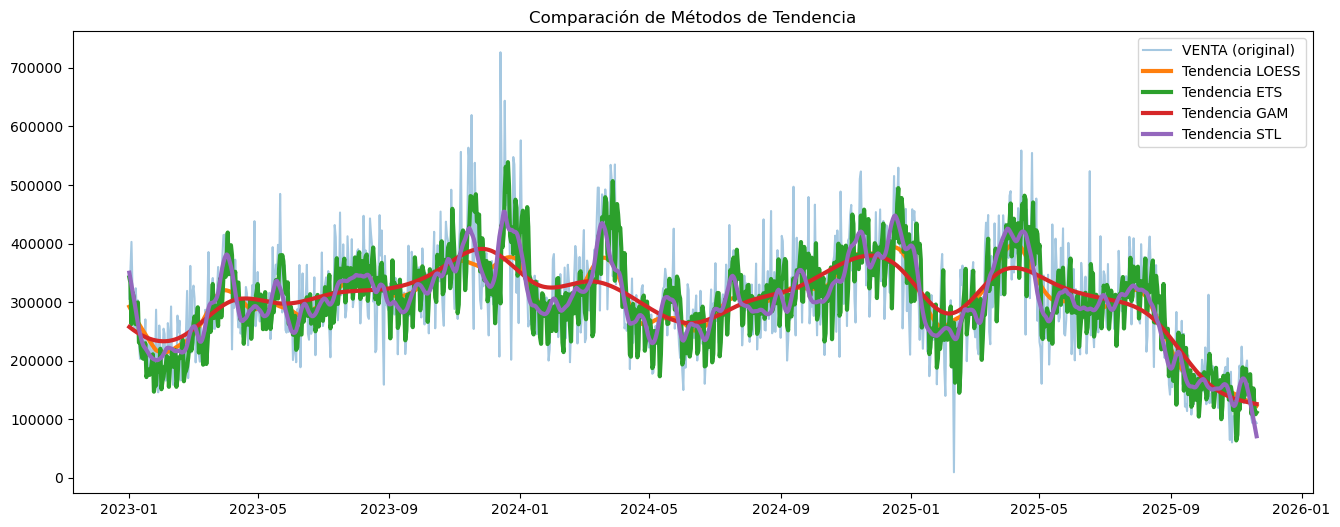

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pygam import LinearGAM, s


# ===========================
# 1. PREPARACIÓN DE DATOS
# ===========================

y = df['VENTA'].astype(float).values
t = np.arange(len(y))  # eje temporal numérico para GAM

res = STL(y, period=7, robust=True).fit()
# ===========================
# 2. LOESS (suavización local)
# ===========================

loess_smoothed = lowess(y, t, frac=0.05)[:, 1]  
# Puedes ajustar frac: 0.03 más suave, 0.1 más agresivo


# ===========================
# 3. ETS (Holt-Winters sin estacionalidad)
# ===========================

ets_model = ExponentialSmoothing(df, trend='add', seasonal='add')
ets_fit = ets_model.fit()
ets_trend = ets_fit.fittedvalues


# ===========================
# 4. GAM (el mejor modelo moderno)
# ===========================

gam = LinearGAM(s(0, n_splines=25, spline_order=3)).fit(t.reshape(-1,1), y)
gam_trend = gam.predict(t)


# ===========================
# 5. GRÁFICAS DE COMPARACIÓN
# ===========================

plt.figure(figsize=(16,6))

plt.plot(df.index, y, alpha=0.4, label='VENTA (original)')
plt.plot(df.index, loess_smoothed, label='Tendencia LOESS', linewidth=3)
plt.plot(df.index, ets_trend, label='Tendencia ETS', linewidth=3)
plt.plot(df.index, gam_trend, label='Tendencia GAM', linewidth=3)
plt.plot(df.index,res.trend,label='Tendencia STL', linewidth=3)

plt.legend()
plt.title("Comparación de Métodos de Tendencia")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import windows

# Supongamos que df ya está cargado y tiene la columna 'VENTA'
# --- Preparación de datos ---
series = df['VENTA'].values
n = len(series)
dt = 1  # Frecuencia de muestreo (1 día)

## 1. 🧹 DETRENDING: Remoción del Valor Medio (DC Offset)
# Esto es crucial para que el pico DC no domine el espectro.
series_detrended = series - np.mean(series)

## 2. 🌬️ VENTANEO: Aplicación de la Ventana de Hanning
# Reduce la fuga espectral (spectral leakage) causada por el truncamiento.
hanning_window = windows.hann(n)
series_windowed = series_detrended * hanning_window

# --- FFT ---
# Aplicamos la FFT a la serie limpia (sin offset y con ventana)
fft_vals = rfft(series_windowed)
fft_freqs = rfftfreq(n, dt)

# Obtener amplitud (Magnitud del espectro)
amplitudes = np.abs(fft_vals)

# --- Análisis del Espectro ---

# Ignorar la frecuencia cero (DC component, que ya debe ser muy baja post-detrending)
fft_freqs = fft_freqs[1:]
amplitudes = amplitudes[1:]

# Calcular el periodo dominante
# np.argmax encuentra el índice de la amplitud máxima
dominant_freq = fft_freqs[np.argmax(amplitudes)]
dominant_period = 1 / dominant_freq

print("--- Resultados del Análisis Espectral ---")
print(f"Período dominante estimado: {dominant_period:.2f} días")

# --- Graficar espectro ---
plt.figure(figsize=(10, 4))
# Convertimos el eje de frecuencia (Hz o ciclos/día) a Periodo (días)
plt.plot(1/fft_freqs, amplitudes)
plt.xlabel("Período (días)")
plt.ylabel("Amplitud (Energía)")
plt.title("Espectro de Amplitud (FFT) con Detrending y Ventaneo")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, n) # Limitar el eje X a la mitad del tamaño de la serie para mejor visualización
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 2. Gráfica de Autocorrelación (ACF) ---
plt.figure(figsize=(12, 4))
plot_acf(series_detrended, lags=60, title='ACF')
plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.show()

# --- 3. Gráfica de Autocorrelación Parcial (PACF) ---
plt.figure(figsize=(12, 4))
plot_pacf(series_detrended, lags=60, title='PACF')
plt.xlabel("Lag")
plt.ylabel("Autocorrelación Parcial")
plt.show()

In [ ]:
df_ = series_detrended.copy()
n = 30  # Se define el número máximo de lags a considerar para el análisis.
acf_valores, acf_conf = acf(df_, nlags=n, alpha=0.05)
pacf_valores, pacf_conf = pacf(df_, nlags=n, alpha=0.05, method='ywm')

acf_significativos = np.where(np.abs(acf_valores[1:]) > (acf_conf[1:, 1] - acf_valores[1:]))[0] + 1
pacf_significativos = np.where(np.abs(pacf_valores[1:]) > (pacf_conf[1:, 1] - pacf_valores[1:]))[0] + 1

acf_significativos, pacf_significativos

In [ ]:
lags_a_verificar = np.array([7, 14, 28, 30])
mascara_pertenencia = np.isin(lags_a_verificar, acf_significativos)
lags_encontrados = lags_a_verificar[mascara_pertenencia]

In [ ]:
scores= []

for period in lags_encontrados:
    res = STL(series, period=period, robust=True).fit()
    scores.append(float(np.var(res.seasonal) / np.var(series) if np.var(series) > 0 else 0.0))
    plt.figure(figsize=(10,6))
    plt.plot(series)
    plt.plot(res.trend)
    plt.plot(res.seasonal)
    plt.plot(res.resid)

In [ ]:
scores